# 04 — Advanced Modeling: XGBoost + LSTM
**Amreen**

Two advanced models, each attacking the problem differently:
- **XGBoost** — tabular, fast, interpretable via feature importance
- **LSTM** — sequence model that sees the full degradation trajectory

Both are tracked with MLflow so experiments are reproducible.


In [13]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np, mlflow, mlflow.sklearn
from sklearn.model_selection import GroupShuffleSplit
import warnings; warnings.filterwarnings('ignore')

from src.models.xgboost_model import XGBRULModel, XGBClassifier
from src.models.evaluate       import evaluate_rul, evaluate_classifier
from src.features.build_features import get_feature_cols

mlflow.set_experiment('predictive-asset-health')
print("MLflow experiment set")

2026/07/07 01:32:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 01:32:11 INFO mlflow.store.db.utils: Updating database tables
2026/07/07 01:32:13 INFO mlflow.tracking.fluent: Experiment with name 'predictive-asset-health' does not exist. Creating a new experiment.


MLflow experiment set


In [14]:
train_feat = pd.read_csv('../data/processed/train_features.csv')
feat_cols  = get_feature_cols(train_feat)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train_feat, groups=train_feat['unit_id']))
trn = train_feat.iloc[train_idx]
val = train_feat.iloc[val_idx]

## XGBoost — RUL regression

In [15]:
with mlflow.start_run(run_name='xgb-rul'):
    xgb_rul = XGBRULModel()
    xgb_rul.fit(trn[feat_cols], trn['rul'],
                val[feat_cols], val['rul'])

    preds   = xgb_rul.predict(val[feat_cols])
    metrics = evaluate_rul(val['rul'].values, preds, label='XGBoost RUL')

    mlflow.log_params(xgb_rul.params)
    mlflow.log_metrics({'rmse': metrics['rmse'], 'mae': metrics['mae'], 'nasa_score': metrics['nasa_score']})

    xgb_rul.save('../models/artifacts/xgb_rul.pkl')


── XGBoost RUL — RUL Regression ──
  RMSE        : 63.38 cycles
  MAE         : 51.46 cycles
  NASA Score  : 190816455  (lower is better)
  saved to ../models/artifacts/xgb_rul.pkl


## Feature Importance — what drives RUL predictions?

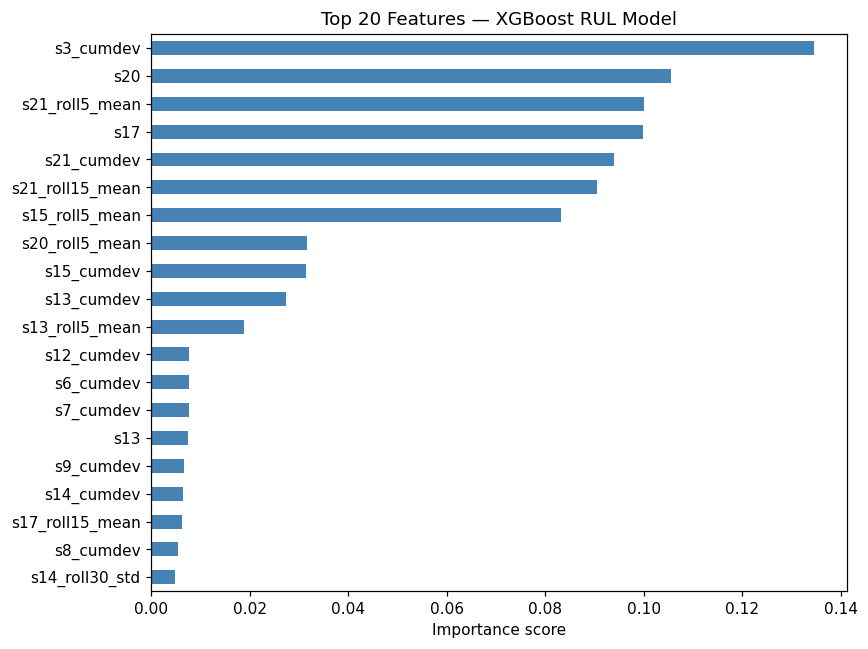

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

fi = xgb_rul.feature_importance().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
fi[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Features — XGBoost RUL Model')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

## XGBoost — Failure classifier

In [17]:
with mlflow.start_run(run_name='xgb-classifier'):
    xgb_clf = XGBClassifier()
    xgb_clf.fit(trn[feat_cols], trn['will_fail'],
                val[feat_cols], val['will_fail'])

    probas  = xgb_clf.predict_proba(val[feat_cols])
    metrics = evaluate_classifier(val['will_fail'].values, probas, label='XGBoost Classifier')

    mlflow.log_metrics({'auc': metrics['auc'], 'f1': metrics['f1'],
                        'precision': metrics['precision'], 'recall': metrics['recall']})

    xgb_clf.save('../models/artifacts/xgb_clf.pkl')


── XGBoost Classifier — Failure Classifier (threshold=0.5) ──
  AUC         : 0.8447
  F1          : 0.4338
  Precision   : 0.4695
  Recall      : 0.4032
  Confusion Matrix:
[[2949  226]
 [ 296  200]]
  saved to ../models/artifacts/xgb_clf.pkl


## LSTM — RUL (sequence model)

In [18]:
try:
    import torch
    from src.models.lstm_model import LSTMRULModel

    with mlflow.start_run(run_name='lstm-rul'):
        lstm_rul = LSTMRULModel(hidden_size=64, num_layers=2, epochs=20, batch_size=256)
        lstm_rul.fit(trn, feature_cols=feat_cols, val_df=val)

        # for fair comparison, only predict on the last row per unit (same as XGB)
        preds_lstm = lstm_rul.predict(val)
        # align with val labels (predict returns per-row)
        metrics_lstm = evaluate_rul(val['rul'].values, preds_lstm, label='LSTM RUL')

        mlflow.log_metrics({'rmse': metrics_lstm['rmse'], 'nasa_score': metrics_lstm['nasa_score']})
        lstm_rul.save('../models/artifacts/lstm_rul.pt')

except ImportError:
    print("PyTorch not installed — skipping LSTM. Install with: pip install torch")

  Epoch   1/20  train_loss=21804.83
  Epoch   5/20  train_loss=4719.99
  Epoch  10/20  train_loss=453.16
  Epoch  15/20  train_loss=229.89
  Epoch  20/20  train_loss=194.15

── LSTM RUL — RUL Regression ──
  RMSE        : 73.24 cycles
  MAE         : 58.17 cycles
  NASA Score  : 1583084574  (lower is better)
  saved to ../models/artifacts/lstm_rul.pt


## Model comparison

In [19]:
print("\n── Model Comparison ──────────────────────────────")
print(f"{'Model':<30} {'RMSE':>8} {'NASA Score':>12}")
print("-" * 52)
# baseline loaded from previous notebook
import joblib
bl = joblib.load('../models/artifacts/baseline_rul.pkl')
bl_preds = bl['pipeline'].predict(val[feat_cols])
from src.models.evaluate import rmse, nasa_score
print(f"{'Linear Regression':<30} {rmse(val['rul'].values, bl_preds):>8.2f} {nasa_score(val['rul'].values, bl_preds):>12.0f}")

xgb_preds = xgb_rul.predict(val[feat_cols])
print(f"{'XGBoost':<30} {rmse(val['rul'].values, xgb_preds):>8.2f} {nasa_score(val['rul'].values, xgb_preds):>12.0f}")


── Model Comparison ──────────────────────────────
Model                              RMSE   NASA Score
----------------------------------------------------
Linear Regression                 73.21     82042233
XGBoost                           63.38    190816455
